# 02 — Frame Extraction & Tensor Preparation Pipeline

## Objective

This notebook implements the complete preprocessing pipeline for:
- reading EchoNet-Dynamic videos
- identifying ED/ES frames
- visualizing cardiac contours
- preprocessing frames
- converting frames into deep learning tensors
- validating PyTorch Dataset/DataLoader integration

---

## Why This Notebook Matters

This notebook forms the foundation for the entire Intern 2 pipeline:

Echo Video → Frame Extraction → Tensor Pipeline → EfficientNet Encoder

The outputs generated here will later be used for:
- image encoder training
- multimodal fusion
- Grad-CAM visualization
- cardiac severity classification

---

## Final Tensor Format

Expected tensor structure:

(Batch, Frames, Channels, Height, Width)

Example:
(4, 2, 3, 224, 224)

Where:
- Batch → number of samples
- Frames → ED + ES
- Channels → RGB
- Height/Width → resized image dimensions

# 1. Imports

In [1]:
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import Dataset, DataLoader

# 2. Dataset Configuration

Define:
- dataset root paths
- video directory
- metadata files
- tracing annotation files

In [3]:
PROJECT_ROOT = Path("../../")

DATA_DIR = PROJECT_ROOT / "data"

ECHONET_DIR = DATA_DIR / "EchoNet-Dynamic"

VIDEOS_DIR = ECHONET_DIR / "Videos"

FILELIST_PATH = ECHONET_DIR / "FileList.csv"

TRACINGS_PATH = ECHONET_DIR / "VolumeTracings.csv"

# 3. Load Metadata

Load:
- FileList.csv
- VolumeTracings.csv

These files contain:
- EF labels
- dataset splits
- contour annotations
- frame-level tracing information

In [4]:
filelist = pd.read_csv(FILELIST_PATH)

tracings = pd.read_csv(TRACINGS_PATH)

print("FileList Shape :", filelist.shape)

print("Tracings Shape :", tracings.shape)

FileList Shape : (10030, 9)
Tracings Shape : (425010, 6)


In [6]:
filelist.head()

,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


In [7]:
tracings.head()

,FileName,X1,Y1,X2,Y2,Frame
0,0X100009310A3BD7FC.avi,51.260417,15.348958,64.932292,69.125000,46
1,0X100009310A3BD7FC.avi,50.037611,17.167841,53.367222,16.321330,46
2,0X100009310A3BD7FC.avi,49.157378,20.407629,57.090549,18.390722,46
3,0X100009310A3BD7FC.avi,48.538173,23.581055,59.997339,20.667707,46
4,0X100009310A3BD7FC.avi,47.918968,26.754480,62.904129,22.944693,46


# 4. Frame Preprocessing Utilities

The preprocessing pipeline performs:
- resizing
- normalization
- tensor conversion
- channel reordering

---

## Target Output Shape

(C, H, W)

Example:
(3, 224, 224)

This format is required by CNN architectures such as EfficientNet.

In [8]:
def preprocess_frame(frame, target_size=(224, 224)):

    frame = cv2.resize(frame, target_size)

    frame = frame.astype(np.float32) / 255.0

    frame = torch.tensor(frame, dtype=torch.float32)

    frame = frame.permute(2, 0, 1)

    return frame

# 5. Contour Visualization Utilities

EchoNet provides ventricular contour annotations.

These contours help:
- visualize cardiac chambers
- validate ED/ES selection
- inspect tracing quality

In [40]:
def draw_contour(frame, contour_points):

    frame_copy = frame.copy()

    contour_points = contour_points.astype(np.int32)

    cv2.polylines(
        frame_copy,
        [contour_points],
        isClosed=True,
        color=(0, 255, 0),
        thickness=1,
        lineType=cv2.LINE_AA
    )

    return frame_copy

# 6. Annotated Frame Discovery

This function identifies frames that contain tracing annotations.

These annotated frames are later used to estimate:
- ED (End Diastole)
- ES (End Systole)

In [41]:
def get_annotated_frames(video_name):

    possible_names = [
        video_name,
        video_name + ".avi"
    ]

    rows = tracings[
        tracings["FileName"].isin(possible_names)
    ]

    frame_counts = rows["Frame"].value_counts()

    return frame_counts.sort_values(ascending=False)

# 7. Sample Video Selection

In [42]:
sample = filelist.sample(1, random_state=42).iloc[0]

video_name = str(sample["FileName"]).strip()

video_file = video_name + ".avi"

video_path = VIDEOS_DIR / video_file

print("Video Path :", video_path)

print("Exists     :", video_path.exists())

Video Path : ../../data/EchoNet-Dynamic/Videos/0X383838D5E679ACFE.avi
Exists     : True


# 8. ED/ES Frame Identification

Using tracing frequency information to estimate:
- ED frame
- ES frame

This provides a stronger approximation than naive temporal selection.

In [43]:
frame_counts = get_annotated_frames(video_name)

frame_counts.head()

Frame
133    63
115    21
Name: count, dtype: int64

In [44]:
annotated_frames = sorted(frame_counts.index.tolist())

if len(annotated_frames) == 0:
    raise ValueError("No annotated frames found")

ed_idx = annotated_frames[0]

es_idx = annotated_frames[-1]

print("ED Frame :", ed_idx)

print("ES Frame :", es_idx)

ED Frame : 115
ES Frame : 133


# 9. Video Loading

In [45]:
cap = cv2.VideoCapture(str(video_path))

print("Video Opened :", cap.isOpened())

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fps = cap.get(cv2.CAP_PROP_FPS)

print("Total Frames :", total_frames)

print("FPS          :", fps)

Video Opened : True
Total Frames : 172
FPS          : 50.0


# 10. Frame Extraction

Read all video frames into memory.

Frames are converted:
BGR → RGB
for compatibility with:
- matplotlib
- torchvision
- deep learning pipelines

In [46]:
frames = []

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frames.append(frame_rgb)

cap.release()

print("Extracted Frames :", len(frames))

Extracted Frames : 172


In [47]:
print("Single Frame Shape :", frames[0].shape)

Single Frame Shape : (112, 112, 3)


# 11. ED/ES Frame Extraction

In [48]:
ed_frame = frames[ed_idx]

es_frame = frames[es_idx]

print("ED Shape :", ed_frame.shape)

print("ES Shape :", es_frame.shape)

ED Shape : (112, 112, 3)
ES Shape : (112, 112, 3)


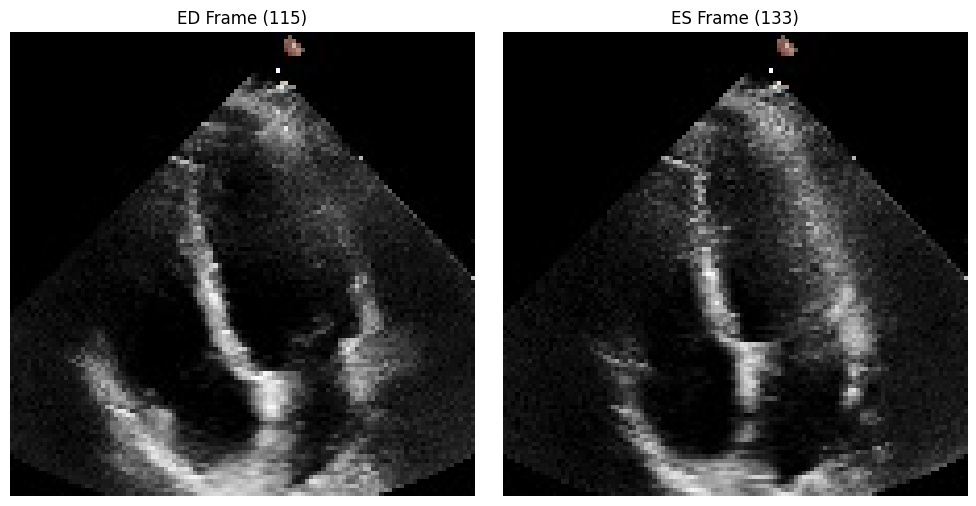

In [49]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(ed_frame)

plt.title(f"ED Frame ({ed_idx})")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(es_frame)

plt.title(f"ES Frame ({es_idx})")

plt.axis("off")

plt.tight_layout()

plt.show()

# 12. Contour Extraction

Retrieve contour points corresponding to:
- ED frame
- ES frame

In [50]:
ed_points = tracings[
    (tracings["FileName"].isin([video_name, video_file])) &
    (tracings["Frame"] == ed_idx)
]

es_points = tracings[
    (tracings["FileName"].isin([video_name, video_file])) &
    (tracings["Frame"] == es_idx)
]

In [51]:
ed_contour = np.concatenate([
    ed_points[["X1", "Y1"]].values,
    ed_points[["X2", "Y2"]].values[::-1]
])

es_contour = np.concatenate([
    es_points[["X1", "Y1"]].values,
    es_points[["X2", "Y2"]].values[::-1]
])

print("ED Contour Shape :", ed_contour.shape)

print("ES Contour Shape :", es_contour.shape)

ED Contour Shape : (42, 2)
ES Contour Shape : (126, 2)


# 13. Contour Visualization

Overlay tracing annotations on:
- ED frame
- ES frame

This acts as an important preprocessing validation step.

In [52]:
ed_with_contour = draw_contour(ed_frame, ed_contour)

es_with_contour = draw_contour(es_frame, es_contour)

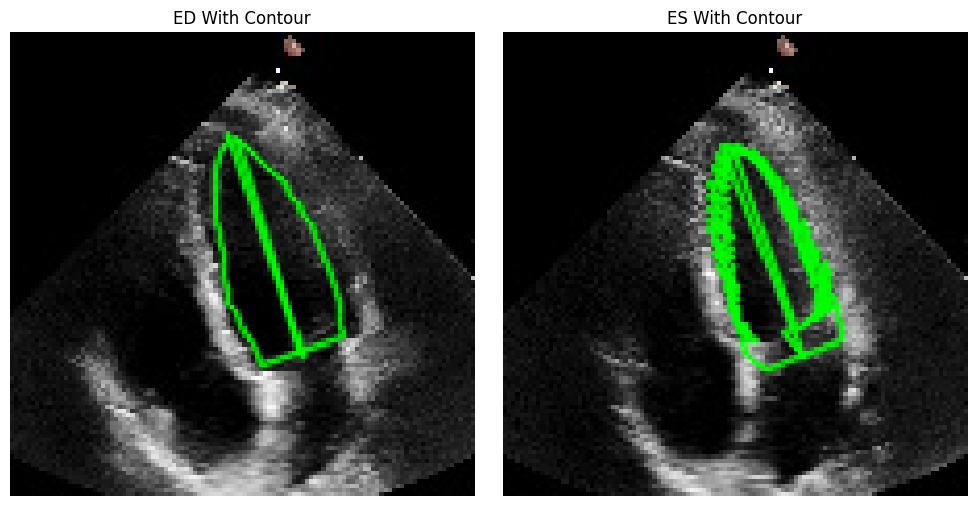

In [53]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(ed_with_contour)

plt.title("ED With Contour")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(es_with_contour)

plt.title("ES With Contour")

plt.axis("off")

plt.tight_layout()

plt.show()

# 14. Frame Preprocessing

Apply:
- resizing
- normalization
- tensor conversion
- channel permutation

In [28]:
ed_tensor = preprocess_frame(ed_frame)

es_tensor = preprocess_frame(es_frame)

print("ED Tensor Shape :", ed_tensor.shape)

print("ES Tensor Shape :", es_tensor.shape)

ED Tensor Shape : torch.Size([3, 224, 224])
ES Tensor Shape : torch.Size([3, 224, 224])


In [29]:
print("Tensor Type :", ed_tensor.dtype)

print("Min Value   :", ed_tensor.min().item())

print("Max Value   :", ed_tensor.max().item())

Tensor Type : torch.float32
Min Value   : 0.0
Max Value   : 0.9411764740943909


# 15. ED/ES Tensor Stacking

Combine:
- ED tensor
- ES tensor

into a single video tensor.

In [30]:
video_tensor = torch.stack([ed_tensor, es_tensor])

print("Video Tensor Shape :", video_tensor.shape)

Video Tensor Shape : torch.Size([2, 3, 224, 224])


# 16. Batch Dimension Addition

Deep learning models expect:
(Batch, Frames, Channels, Height, Width)

In [31]:
batch_tensor = video_tensor.unsqueeze(0)

print("Batch Tensor Shape :", batch_tensor.shape)

Batch Tensor Shape : torch.Size([1, 2, 3, 224, 224])


# 17. GPU Validation

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_tensor = batch_tensor.to(device)

print("Tensor Device :", batch_tensor.device)

Tensor Device : cuda:0


# 18. PyTorch Dataset Abstraction

Create reusable dataset class for:
- training
- validation
- dataloaders
- batching

In [33]:
class EchoDataset(Dataset):

    def __init__(self, filelist, tracings, videos_dir):

        self.filelist = filelist

        self.tracings = tracings

        self.videos_dir = videos_dir

    def __len__(self):

        return len(self.filelist)

    def __getitem__(self, idx):

        row = self.filelist.iloc[idx]

        video_name = str(row["FileName"]).strip()

        video_file = video_name + ".avi"

        video_path = self.videos_dir / video_file

        frame_counts = get_annotated_frames(video_name)

        annotated_frames = sorted(frame_counts.index.tolist())

        ed_idx = annotated_frames[0]

        es_idx = annotated_frames[-1]

        cap = cv2.VideoCapture(str(video_path))

        frames = []

        while True:

            ret, frame = cap.read()

            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            frames.append(frame_rgb)

        cap.release()

        ed_frame = preprocess_frame(frames[ed_idx])

        es_frame = preprocess_frame(frames[es_idx])

        video_tensor = torch.stack([ed_frame, es_frame])

        return video_tensor

# 19. Dataset Validation

In [35]:
dataset = EchoDataset(filelist, tracings, VIDEOS_DIR)

print("Dataset Length :", len(dataset))

Dataset Length : 10030


In [36]:
sample_tensor = dataset[0]

print(type(sample_tensor))

print("Sample Shape :", sample_tensor.shape)

<class 'torch.Tensor'>
Sample Shape : torch.Size([2, 3, 224, 224])


# 20. DataLoader Validation

In [37]:
loader = DataLoader(dataset, batch_size=4)

batch = next(iter(loader))

print("Batch Shape :", batch.shape)

Batch Shape : torch.Size([4, 2, 3, 224, 224])


# 21. Final Pipeline Summary

In [38]:
print("Final Batch Shape :", batch.shape)

print("Tensor Type       :", batch.dtype)

print("Tensor Device     :", batch.device)

print("\n02_frame_extraction.ipynb completed successfully")

Final Batch Shape : torch.Size([4, 2, 3, 224, 224])
Tensor Type       : torch.float32
Tensor Device     : cpu

02_frame_extraction.ipynb completed successfully
